   club_speed_mph  ball_speed_mph  smash_factor  attack_angle_deg  \
0          102.44          139.29         1.371              4.40   
1           91.68          132.71         1.421              8.00   
2          106.00          157.08         1.475             -2.67   
3          107.52          153.51         1.444              5.87   
4           84.39          116.91         1.411              1.71   

   launch_angle_deg  spin_rate_rpm  club_path_deg  face_to_path_deg  \
0             14.62           2437           2.54             -1.20   
1             17.43           2096           2.22              2.90   
2             12.02           3149           1.61             -0.98   
3             17.98           2521           0.22              1.58   
4             12.21           1400          -1.57              0.45   

   offline_yards  carry_yards  good_shot  
0           -1.4        330.0          1  
1           16.7        317.2          1  
2            3.5        330.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6062 - loss: 0.6918 - val_accuracy: 0.6444 - val_loss: 0.6760
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6167 - loss: 0.6754 - val_accuracy: 0.6333 - val_loss: 0.6628
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6712 - loss: 0.6553 - val_accuracy: 0.6389 - val_loss: 0.6548
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6548 - loss: 0.6560 - val_accuracy: 0.6500 - val_loss: 0.6481
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6467 - loss: 0.6511 - val_accuracy: 0.6500 - val_loss: 0.6422
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6664 - loss: 0.6335 - val_accuracy: 0.6556 - val_loss: 0.6369
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6458 - loss: 0.6398 - val_accuracy: 0.6556 - val_loss: 0.6349
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6442 - loss: 0.6398 - val_accuracy: 0.6833 - val_loss: 0.6307
Ep

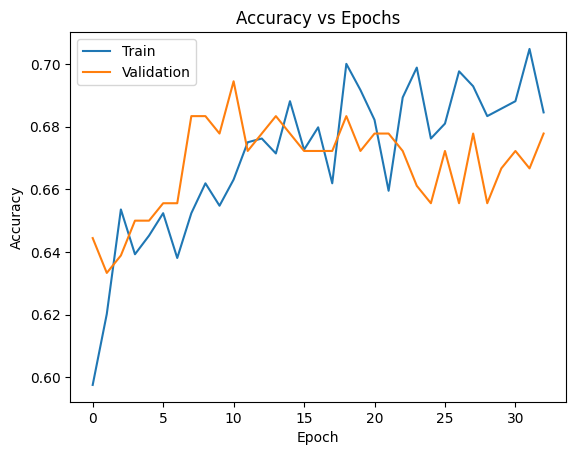

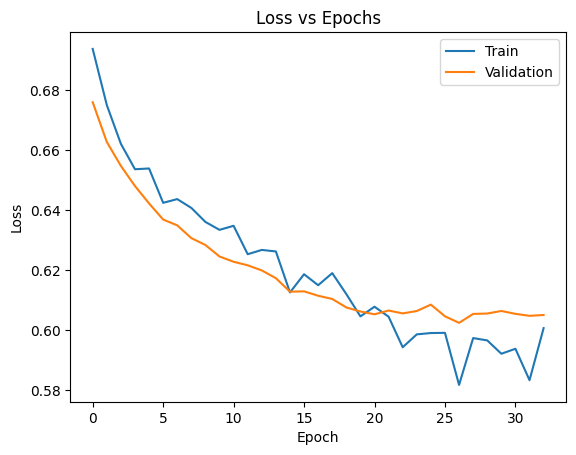

In [3]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def generate_synthetic_golf_dataset(n_rows=1200, filename="synthetic_golf_shots.csv"):
    club_speed = rng.normal(loc=100, scale=8, size=n_rows)   # mph
    club_speed = np.clip(club_speed, 75, 125)

    smash_factor = rng.normal(loc=1.45, scale=0.06, size=n_rows)
    smash_factor = np.clip(smash_factor, 1.20, 1.55)

    ball_speed = club_speed * smash_factor + rng.normal(0, 2.5, n_rows)

    attack_angle = rng.normal(loc=1.5, scale=3.0, size=n_rows)  # deg
    attack_angle = np.clip(attack_angle, -6, 8)

    launch_angle = rng.normal(loc=13.0 + 0.35 * attack_angle, scale=3.0, size=n_rows)
    launch_angle = np.clip(launch_angle, 4, 22)

    spin_rate = rng.normal(loc=2600 - 60 * attack_angle, scale=450, size=n_rows)  # rpm
    spin_rate = np.clip(spin_rate, 1400, 4200)

    club_path = rng.normal(loc=0.0, scale=3.0, size=n_rows)
    club_path = np.clip(club_path, -8, 8)

    face_to_path = rng.normal(loc=0.0, scale=2.5, size=n_rows)
    face_to_path = np.clip(face_to_path, -7, 7)

    offline_yards = (face_to_path * 3.5 + club_path * 1.2) + rng.normal(0, 6, n_rows)
    offline_yards = np.clip(offline_yards, -55, 55)

    carry_yards = (
        2.3 * ball_speed
        + 1.6 * launch_angle
        - 0.0045 * spin_rate
        - 0.12 * np.abs(offline_yards)
        + rng.normal(0, 8, n_rows)
    )
    carry_yards = np.clip(carry_yards, 120, 330)

    z = (
        2.2 * (smash_factor - 1.40)
        + 0.015 * (carry_yards - 210)
        - 0.035 * np.abs(offline_yards)
        - 0.0012 * np.abs(spin_rate - 2600)
        - 0.08 * np.abs(launch_angle - 14)
        - 0.12 * np.abs(face_to_path)
    )

    p_good = sigmoid(z)
    good_shot = rng.binomial(1, p_good, size=n_rows)

    df = pd.DataFrame({
        "club_speed_mph": np.round(club_speed, 2),
        "ball_speed_mph": np.round(ball_speed, 2),
        "smash_factor": np.round(smash_factor, 3),
        "attack_angle_deg": np.round(attack_angle, 2),
        "launch_angle_deg": np.round(launch_angle, 2),
        "spin_rate_rpm": np.round(spin_rate, 0).astype(int),
        "club_path_deg": np.round(club_path, 2),
        "face_to_path_deg": np.round(face_to_path, 2),
        "offline_yards": np.round(offline_yards, 1),
        "carry_yards": np.round(carry_yards, 1),
        "good_shot": good_shot.astype(int)
    })

    df.to_csv(filename, index=False)
    return df

df = generate_synthetic_golf_dataset(n_rows=1200, filename="synthetic_golf_shots.csv")
print(df.head())
print("\nSaved: synthetic_golf_shots.csv")
print("Class balance (good_shot=1):", round(df["good_shot"].mean(), 3))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
df = pd.read_csv("synthetic_golf_shots.csv")

X = df.drop(columns=["good_shot"])
y = df["good_shot"].astype(int)

# Split: train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Build a simple MLP (Deep Learning model)
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_prob = model.predict(X_test_s).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nTEST ACCURACY:", round(acc, 4))
print("\nCONFUSION MATRIX:\n", cm)
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred, digits=4))

# Plot training curves (for your PDF)
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("Accuracy vs Epochs")
plt.show()

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("Loss vs Epochs")
plt.show()
